In [2]:
%pip install pandas matplotlib seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   -- ------------------------------------- 0.8/11.3 MB 2.6 MB/s eta 0:00:05
   --- ------------------------------------ 1.0/11.3 MB 2.1 MB/s eta 0:00:05
   ---- ----------------------------------- 1.3/11.3 MB 2.0 MB/s eta 0:00:06
   ----- ---------------------------------- 1.6/11.3 MB 1.9 MB/s eta 0:00:06
   ------ --------------------------------- 1.8/11.3 MB 1.8 MB/s eta 0:00:06
   ------- -------------------------------- 2.1/11.3 MB 1.6 MB/s eta 0:00:06
   -------- ------------------------------- 2.4/11.3 MB 1.5 MB/s eta 0:00:07
   --------- ------------------------------ 2.6/11.3 MB 1.5 MB/s eta 0:00:06
   ---------- ----------------------------- 2.9/11.3 MB 1.5 MB/s eta 0:00:06
   ------------ ----------------------

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
import warnings
warnings.filterwarnings("ignore")
sns.set(style="whitegrid")

In [5]:
df=pd.read_csv("AIML Dataset.csv")

In [6]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [8]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [9]:
df["isFraud"].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [10]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [11]:
df.shape

(6362620, 11)

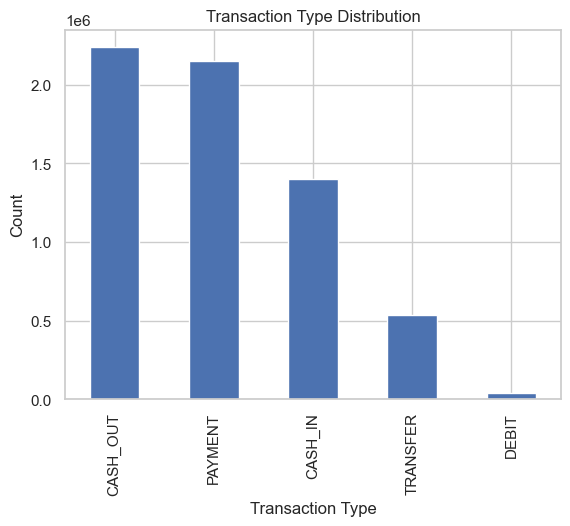

In [12]:
df["type"].value_counts().plot(kind="bar")
plt.title("Transaction Type Distribution")
plt.xlabel("Transaction Type")
plt.ylabel("Count")
plt.show()

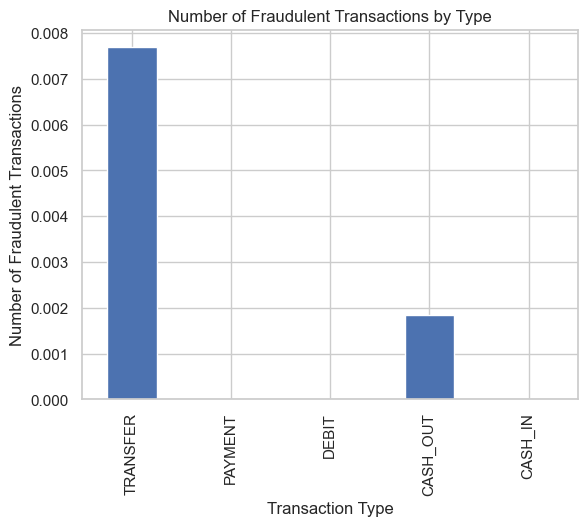

In [13]:
fraud_by_type = df.groupby("type")["isFraud"].mean().sort_index(ascending=False)
fraud_by_type.plot(kind="bar", x="type", y="isFraud", legend=False)
plt.title("Number of Fraudulent Transactions by Type")
plt.xlabel("Transaction Type")
plt.ylabel("Number of Fraudulent Transactions")
plt.show()

In [14]:
fraud_by_type

type
TRANSFER    0.007688
PAYMENT     0.000000
DEBIT       0.000000
CASH_OUT    0.001840
CASH_IN     0.000000
Name: isFraud, dtype: float64

In [15]:
df["amount"].describe()

count    6.362620e+06
mean     1.798619e+05
std      6.038582e+05
min      0.000000e+00
25%      1.338957e+04
50%      7.487194e+04
75%      2.087215e+05
max      9.244552e+07
Name: amount, dtype: float64

In [16]:
df["amount"]

0             9839.64
1             1864.28
2              181.00
3              181.00
4            11668.14
              ...    
6362615     339682.13
6362616    6311409.28
6362617    6311409.28
6362618     850002.52
6362619     850002.52
Name: amount, Length: 6362620, dtype: float64

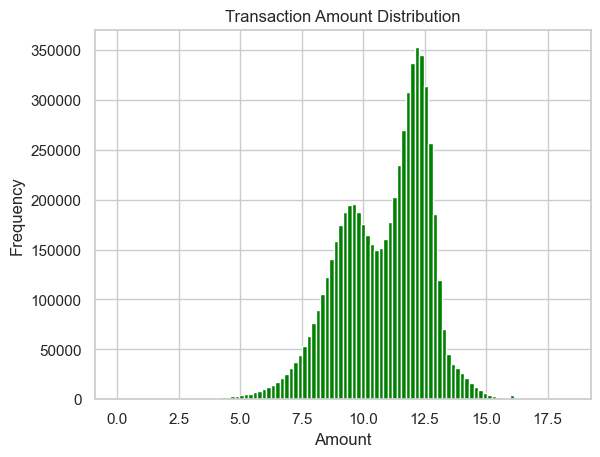

In [17]:
df_amount = np.log1p(df["amount"])
df_amount.plot(kind="hist", bins=100, title="Transaction Amount Distribution",color="green")
plt.xlabel("Amount")
plt.show()

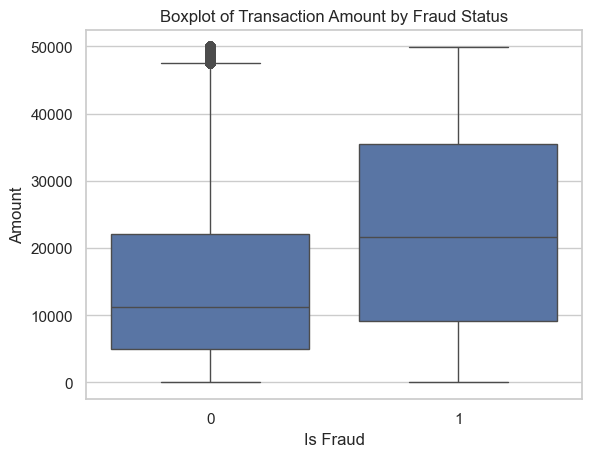

In [18]:
sns.boxplot(data=df[df["amount"] < 50000], x="isFraud", y="amount")
plt.title("Boxplot of Transaction Amount by Fraud Status")
plt.xlabel("Is Fraud")
plt.ylabel("Amount")
plt.show()
# this plot answers the question of whether fraudulent transactions tend to have higher amounts compared to non-fraudulent ones. If the boxplot shows that the median and upper quartiles of the fraudulent transactions are significantly higher than those of the non-fraudulent transactions, it would suggest that fraudulent transactions generally involve larger amounts.

In [19]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [20]:
df["balanceDiffOrig"]=df["oldbalanceOrg"]-df["newbalanceOrig"]
df["balanceDiffDest"]= df["newbalanceDest"]-df["oldbalanceDest"]

In [21]:
(df["balanceDiffOrig"]<0).sum()

np.int64(1399253)

In [22]:
(df["balanceDiffDest"]<0).sum()

np.int64(1238864)

In [23]:
df.head(2)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrig,balanceDiffDest
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,9839.64,0.0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,1864.28,0.0


In [24]:
df["step"].value_counts()

step
19     51352
18     49579
187    49083
235    47491
307    46968
       ...  
706        4
721        4
693        4
112        2
662        2
Name: count, Length: 743, dtype: int64

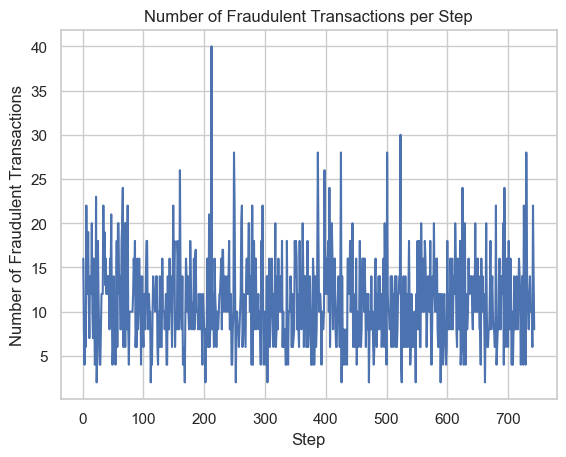

In [25]:
fraud_per_step = df[df["isFraud"] == 1]["step"].value_counts().sort_index()
plt.plot(fraud_per_step.index, fraud_per_step.values)
plt.title("Number of Fraudulent Transactions per Step")
plt.xlabel("Step")
plt.ylabel("Number of Fraudulent Transactions")
plt.show()

In [26]:
top_senders = df["nameOrig"].value_counts().head(10)

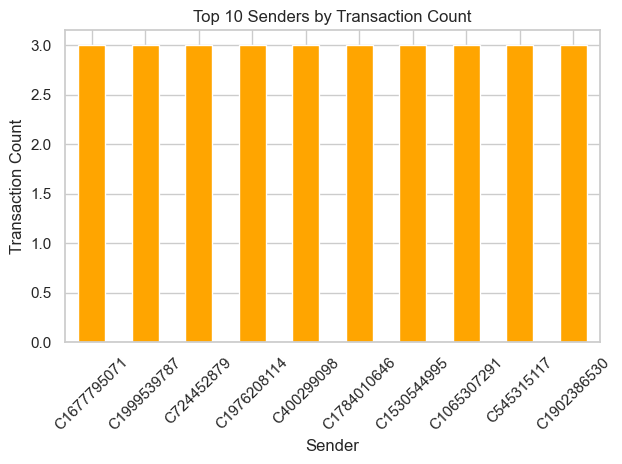

In [27]:
top_senders.plot(kind="bar", color="orange")
plt.title("Top 10 Senders by Transaction Count")
plt.xlabel("Sender")
plt.ylabel("Transaction Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()  

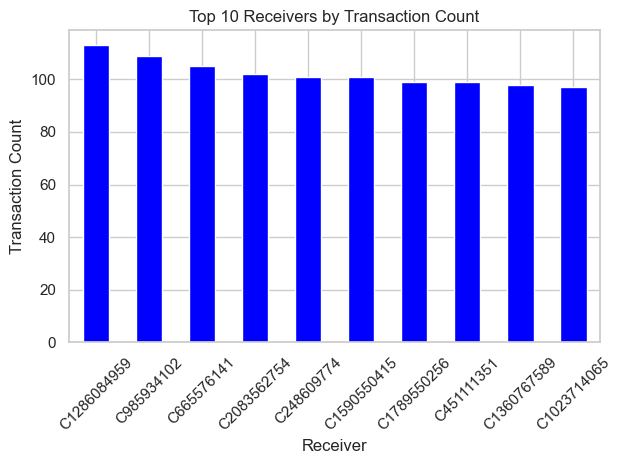

In [28]:
top_receivers = df["nameDest"].value_counts().head(10)
top_receivers.plot(kind="bar", color="blue")
plt.title("Top 10 Receivers by Transaction Count")
plt.xlabel("Receiver")
plt.ylabel("Transaction Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

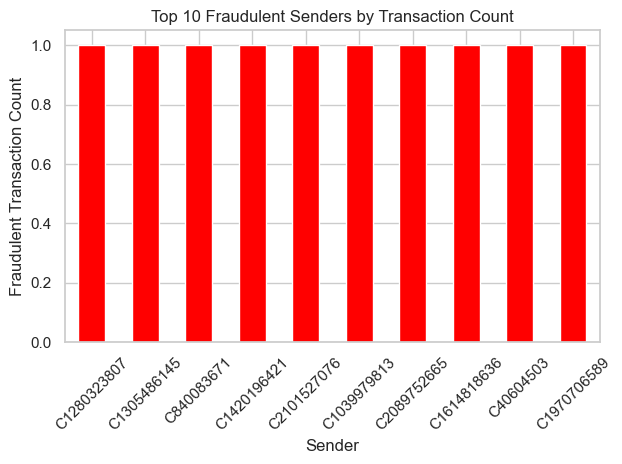

In [29]:
fraud_users = df[df["isFraud"] == 1]["nameOrig"].value_counts().head(10)
fraud_users.plot(kind="bar", color="red")
plt.title("Top 10 Fraudulent Senders by Transaction Count")
plt.xlabel("Sender")
plt.ylabel("Fraudulent Transaction Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()  

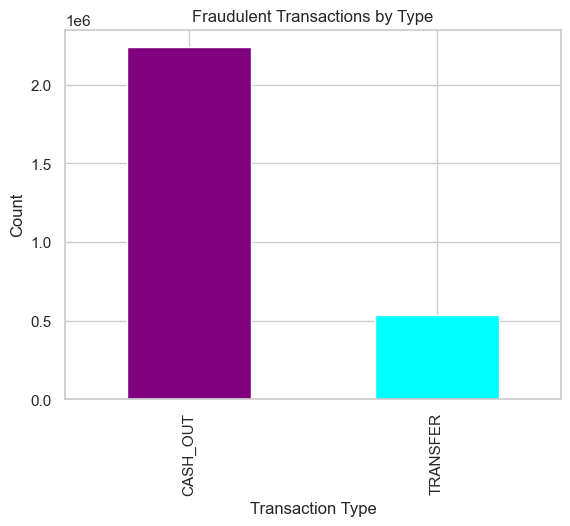

In [30]:
fraud_types = df[df["type"].isin(["TRANSFER", "CASH_OUT"])]["type"].value_counts()
fraud_types.plot(kind="bar", color=["purple", "cyan"])
plt.title("Fraudulent Transactions by Type")
plt.xlabel("Transaction Type")
plt.ylabel("Count")
plt.show()

In [31]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud', 'balanceDiffOrig', 'balanceDiffDest'],
      dtype='object')

In [32]:
# now i want to check the correlation between the  amount of the money and old 
# and new balance of the sender and receiver to see if there is a correlation between them and the fraud transactions
corr = df[["amount", "oldbalanceOrg", "newbalanceOrig", "oldbalanceDest", "newbalanceDest","isFraud"]].corr()
corr

,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
amount,1.000000,-0.002762,-0.007861,0.294137,0.459304,0.076688
oldbalanceOrg,-0.002762,1.000000,0.998803,0.066243,0.042029,0.010154
newbalanceOrig,-0.007861,0.998803,1.000000,0.067812,0.041837,-0.008148
oldbalanceDest,0.294137,0.066243,0.067812,1.000000,0.976569,-0.005885
newbalanceDest,0.459304,0.042029,0.041837,0.976569,1.000000,0.000535
isFraud,0.076688,0.010154,-0.008148,-0.005885,0.000535,1.000000


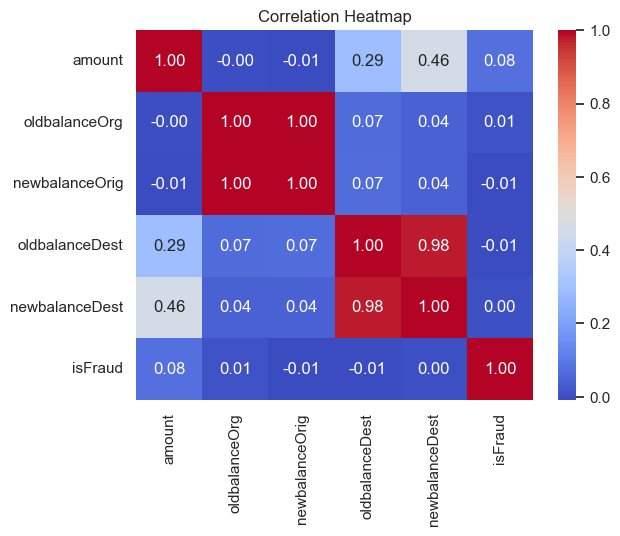

In [33]:
# heat map of the correlation
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [34]:
zero_after_transactions = df[(df["oldbalanceOrg"] > 0) & (df["newbalanceOrig"] == 0) & (df["type"].isin(["TRANSFER", "CASH_OUT"]))]

In [35]:
zero_after_transactions.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrig,balanceDiffDest
2,1,TRANSFER,181.00,C1305486145,181.0,0.0,C553264065,0.0,0.00,1,0,181.0,0.00
3,1,CASH_OUT,181.00,C840083671,181.0,0.0,C38997010,21182.0,0.00,1,0,181.0,-21182.00
15,1,CASH_OUT,229133.94,C905080434,15325.0,0.0,C476402209,5083.0,51513.44,0,0,15325.0,46430.44
19,1,TRANSFER,215310.30,C1670993182,705.0,0.0,C1100439041,22425.0,0.00,0,0,705.0,-22425.00
24,1,TRANSFER,311685.89,C1984094095,10835.0,0.0,C932583850,6267.0,2719172.89,0,0,10835.0,2712905.89


In [36]:
persons=len(zero_after_transactions)
print(f"Number of transactions where the sender's balance goes to zero after the transaction: {persons}")

Number of transactions where the sender's balance goes to zero after the transaction: 1188074


In [37]:
zero_after_transactions.groupby("type")["isFraud"].value_counts().unstack()

isFraud,0,1
type,,
CASH_OUT,955334,4078
TRANSFER,224728,3934


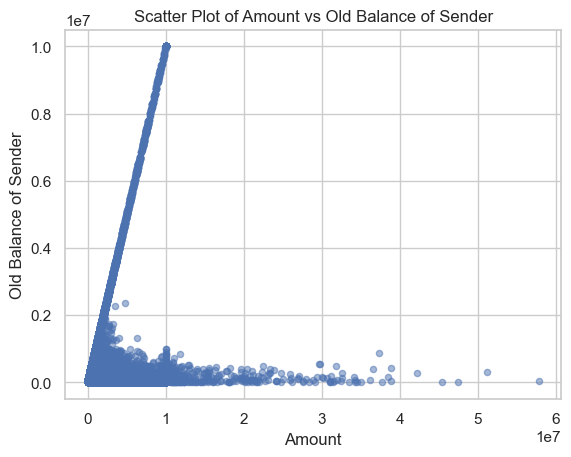

In [38]:
zero_after_transactions.plot(kind="scatter", x="amount", y="oldbalanceOrg", alpha=0.5)
plt.title("Scatter Plot of Amount vs Old Balance of Sender")
plt.xlabel("Amount")
plt.ylabel("Old Balance of Sender")
plt.show()

In [39]:
df["isFraud"].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [40]:
# so the  datais imbalanced and we have a lot of techniques we have to deal  with

In [42]:
%pip install imbalanced-learn
%pip install sklearn

  Using cached imbalanced_learn-0.14.1-py3-none-any.whl.metadata (8.9 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
   ---------------------------------------- 0.0/8.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.9 MB ? eta -:--:--
   --- ------------------------------------ 0.8/8.9 MB 3.7 MB/s eta 0:00:03
   ------- -------------------------------- 1.6/8.9 MB 3.1 MB/s eta 0:00:03
   --------- ------------------------------ 2.1/8.9 MB 3.0 MB/s eta 0:00:03
   ----------- ---------------------------- 2.6/8.9 MB 2.9 MB/s eta 0:00:03
   -------------- ------------------------- 3.1/8.9 MB 2.8 MB/s eta 0:00:03
   ---------------- ----------------------- 3.7/8.9 MB 2.8 MB/s eta 0:00:02
   ------------------ --------------------- 4.2/8.9 MB 2.7 MB/s eta 0:00:02
   -------------------- ------------------- 4.5/8.9 MB 2.7 MB/s eta 0:00

  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [15 lines of output]
      The 'sklearn' PyPI package is deprecated, use 'scikit-learn'
      rather than 'sklearn' for pip commands.
      
      Here is how to fix this error in the main use cases:
      - use 'pip install scikit-learn' rather than 'pip install sklearn'
      - replace 'sklearn' by 'scikit-learn' in your pip requirements files
        (requirements.txt, setup.py, setup.cfg, Pipfile, etc ...)
      - if the 'sklearn' package is used by one of your dependencies,
        it would be great if you take some time to track which package uses
        'sklearn' instead of 'scikit-learn' and report it to their issue tracker
      - as a last resort, set the environment variable
        SKLEARN_ALLOW_DEPRECATED_SKLEARN_PACKAGE_INSTALL=True to avoid this error
      
      More information is available at
      https://github.com/scikit-learn/sklearn-

In [43]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.compose import ColumnTransformer


In [48]:
df.columns

Index(['type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud', 'balanceDiffOrig', 'balanceDiffDest'],
      dtype='object')

In [49]:
df.head()

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrig,balanceDiffDest
0,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,9839.64,0.0
1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,1864.28,0.0
2,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,181.00,0.0
3,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,181.00,-21182.0
4,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,11668.14,0.0


In [50]:
# now i have to execlude columns from training w.r.t the target column IsFraud

In [51]:
df_model = df.drop(columns=["nameOrig", "nameDest", "isFlaggedFraud"], inplace=False, axis=1)

In [52]:
df_model.head()

,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,balanceDiffOrig,balanceDiffDest
0,PAYMENT,9839.64,170136.0,160296.36,0.0,0.0,0,9839.64,0.0
1,PAYMENT,1864.28,21249.0,19384.72,0.0,0.0,0,1864.28,0.0
2,TRANSFER,181.00,181.0,0.00,0.0,0.0,1,181.00,0.0
3,CASH_OUT,181.00,181.0,0.00,21182.0,0.0,1,181.00,-21182.0
4,PAYMENT,11668.14,41554.0,29885.86,0.0,0.0,0,11668.14,0.0


In [53]:
categorical_features = ["type"]
numerical_features = [col for col in df_model.columns if col not in categorical_features + ["isFraud"]]

In [54]:
print("Categorical Features:", categorical_features)
print("Numerical Features:", numerical_features)

Categorical Features: ['type']
Numerical Features: ['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'balanceDiffOrig', 'balanceDiffDest']


In [55]:
y= df_model["isFraud"]
X = df_model.drop(columns=["isFraud"],axis=1)

In [56]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [57]:
smote = SMOTE(random_state=42)

In [58]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(drop='first'), categorical_features)
    ],
    remainder="drop"
)
# it means drop="first" will drop the first category of the "type" feature, which is typically done to avoid multicollinearity in the model.
# and remainder="drop" means that any columns not specified in the transformers list will be dropped from the output of the ColumnTransformer. This is useful when you only want to apply transformations to a subset of the features and ignore the rest.

In [59]:
pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(class_weight="balanced", max_iter=1000))
])

In [60]:
pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [61]:
y_pred=pipeline.predict(X_test)

In [62]:
classification_rep = classification_report(y_test, y_pred)
print("Classification Report:\n", classification_rep)

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.95      0.97   1906322
           1       0.02      0.94      0.04      2464

    accuracy                           0.95   1908786
   macro avg       0.51      0.94      0.51   1908786
weighted avg       1.00      0.95      0.97   1908786



In [87]:
pipeline.score(X_test,y_test)

0.9473762380905979

In [88]:
import joblib
joblib.dump(pipeline, "fraud_model.pkl")

['fraud_model.pkl']

In [64]:
%pip install imblearn

  Using cached imblearn-0.0-py2.py3-none-any.whl.metadata (355 bytes)
Using cached imblearn-0.0-py2.py3-none-any.whl (1.9 kB)
Note: you may need to restart the kernel to use updated packages.


In [66]:
%pip install xgboost

  Using cached xgboost-3.2.0-py3-none-win_amd64.whl.metadata (2.1 kB)
Using cached xgboost-3.2.0-py3-none-win_amd64.whl (101.7 MB)
Note: you may need to restart the kernel to use updated packages.


In [67]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.metrics import f1_score, precision_score, recall_score, classification_report

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

from xgboost import XGBClassifier

# ============================================================
# LOAD DATA
# ============================================================

df_test = pd.read_csv("AIML Dataset.csv")

# ============================================================
# FEATURE ENGINEERING
# ============================================================

df_test["balanceDiffOrig"] = df_test["oldbalanceOrg"] - df_test["newbalanceOrig"]
df_test["balanceDiffDest"] = df_test["newbalanceDest"] - df_test["oldbalanceDest"]
df_test["amount_log"] = np.log1p(df_test["amount"])

df_test.drop(["nameOrig", "nameDest"], axis=1, inplace=True)

# ============================================================
# FEATURES / TARGET
# ============================================================

X = df_test.drop("isFraud", axis=1)
y = df_test["isFraud"]

# ============================================================
# TRAIN / TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ============================================================
# PREPROCESSOR
# ============================================================

numerical_features = X.select_dtypes(include=np.number).columns
categorical_features = ["type"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(drop="first"), categorical_features)
    ],
    remainder="drop"
)

# ============================================================
# BASE MODEL
# ============================================================

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    eval_metric="logloss",
    random_state=42
)

# ============================================================
# 1. BASELINE (NO SMOTE)
# ============================================================

baseline_model = Pipeline([
    ("preprocess", preprocessor),
    ("model", xgb)
])

baseline_model.fit(X_train, y_train)
y_pred_base = baseline_model.predict(X_test)

# ============================================================
# 2. WITH SMOTE
# ============================================================

smote_model = ImbPipeline([
    ("preprocess", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("model", xgb)
])

smote_model.fit(X_train, y_train)
y_pred_smote = smote_model.predict(X_test)

# ============================================================
# 3. CLASS WEIGHT (BEST PRACTICE)
# ============================================================

scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

xgb_weighted = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight,
    random_state=42
)

weighted_model = Pipeline([
    ("preprocess", preprocessor),
    ("model", xgb_weighted)
])

weighted_model.fit(X_train, y_train)
y_pred_weighted = weighted_model.predict(X_test)

# ============================================================
# EVALUATION FUNCTION
# ============================================================

def evaluate(name, y_true, y_pred):
    print(f"\n================ {name} ================")
    print("F1:", f1_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall:", recall_score(y_true, y_pred))
    print(classification_report(y_true, y_pred))

# ============================================================
# RESULTS
# ============================================================

evaluate("BASELINE (NO SMOTE)", y_test, y_pred_base)
evaluate("WITH SMOTE", y_test, y_pred_smote)
evaluate("CLASS WEIGHT (XGBOOST)", y_test, y_pred_weighted)

# ============================================================
# BEST MODEL SELECTION
# ============================================================

scores = {
    "baseline": f1_score(y_test, y_pred_base),
    "smote": f1_score(y_test, y_pred_smote),
    "weighted": f1_score(y_test, y_pred_weighted)
}

best_model_name = max(scores, key=scores.get)

print("\n================ BEST MODEL ================")
print("Best Model:", best_model_name)
print("Best F1 Score:", scores[best_model_name])


================ BASELINE (NO SMOTE) ================
F1: 0.8988617886178861
Precision: 0.9650837988826816
Recall: 0.8411442483262325
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.97      0.84      0.90      1643

    accuracy                           1.00   1272524
   macro avg       0.98      0.92      0.95   1272524
weighted avg       1.00      1.00      1.00   1272524


================ WITH SMOTE ================
F1: 0.44387061701549335
Precision: 0.2857392825896763
Recall: 0.9939135727328059
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.29      0.99      0.44      1643

    accuracy                           1.00   1272524
   macro avg       0.64      1.00      0.72   1272524
weighted avg       1.00      1.00      1.00   1272524


================ CLASS WEIGHT (XGBOOST) ================
F1: 0.5003837298541827
Pre

In [71]:
%pip install evidently

Note: you may need to restart the kernel to use updated packages.


In [77]:
# # ============================================================
# # FRAUD DETECTION PIPELINE - AIML DATASET
# # SHAP + FEATURE SELECTION + SMOTE + DRIFT
# # ============================================================

# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# import shap
# import joblib

# from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import StandardScaler, OneHotEncoder
# from sklearn.compose import ColumnTransformer
# from sklearn.pipeline import Pipeline
# from sklearn.metrics import f1_score, classification_report

# from imblearn.over_sampling import SMOTE
# from imblearn.pipeline import Pipeline as ImbPipeline

# from xgboost import XGBClassifier

# from evidently import Report
# from evidently.presets import DataDriftPreset

# # ============================================================
# # 1. LOAD DATA (AIML DATASET)
# # ============================================================

# df = pd.read_csv("AIML Dataset.csv")

# # ============================================================
# # 2. FEATURE ENGINEERING
# # ============================================================

# df["balanceDiffOrig"] = df["oldbalanceOrg"] - df["newbalanceOrig"]
# df["balanceDiffDest"] = df["newbalanceDest"] - df["oldbalanceDest"]
# df["amount_log"] = np.log1p(df["amount"])

# df.drop(["nameOrig", "nameDest"], axis=1, inplace=True)

# # ============================================================
# # 3. SPLIT FEATURES
# # ============================================================

# X = df.drop("isFraud", axis=1)
# y = df["isFraud"]

# X_train, X_test, y_train, y_test = train_test_split(
#     X, y,
#     test_size=0.2,
#     random_state=42,
#     stratify=y
# )

# # ============================================================
# # 4. PREPROCESSOR
# # ============================================================

# num_features = X.select_dtypes(include=np.number).columns
# cat_features = ["type"]

# preprocessor = ColumnTransformer([
#     ("num", StandardScaler(), num_features),
#     ("cat", OneHotEncoder(drop="first"), cat_features)
# ])

# # ============================================================
# # 5. BASE MODEL (XGBOOST)
# # ============================================================

# xgb = XGBClassifier(
#     n_estimators=200,
#     max_depth=6,
#     learning_rate=0.1,
#     eval_metric="logloss",
#     random_state=42
# )

# baseline_model = Pipeline([
#     ("prep", preprocessor),
#     ("model", xgb)
# ])

# baseline_model.fit(X_train, y_train)

# # ============================================================
# # 6. SHAP FEATURE IMPORTANCE (VERY IMPORTANT STEP)
# # ============================================================

# print("\nRunning SHAP for feature selection...")

# X_train_trans = preprocessor.fit_transform(X_train)
# X_test_trans = preprocessor.transform(X_test)

# explainer = shap.TreeExplainer(xgb)
# xgb.fit(X_train_trans, y_train)

# shap_values = explainer.shap_values(X_test_trans)

# # SHAP summary
# shap.summary_plot(shap_values, X_test_trans)

# # Get feature importance
# feature_names = preprocessor.get_feature_names_out()

# shap_importance = np.abs(shap_values).mean(axis=0)

# shap_df = pd.DataFrame({
#     "feature": feature_names,
#     "importance": shap_importance
# }).sort_values(by="importance", ascending=False)

# print("\nSHAP Feature Importance:")
# print(shap_df)

# # ============================================================
# # 7. SELECT TOP FEATURES (FEATURE SELECTION)
# # ============================================================

# top_features = shap_df["feature"].head(8).tolist()

# print("\nTop Features Selected:")
# print(top_features)

# # ============================================================
# # 8. REBUILD DATA WITH SELECTED FEATURES ONLY
# # ============================================================

# X_train_sel = pd.DataFrame(X_train_trans, columns=feature_names)[top_features]
# X_test_sel = pd.DataFrame(X_test_trans, columns=feature_names)[top_features]

# # ============================================================
# # 9. MODEL 1: WITHOUT SMOTE
# # ============================================================

# model_no_smote = XGBClassifier(
#     n_estimators=200,
#     max_depth=6,
#     learning_rate=0.1,
#     eval_metric="logloss",
#     random_state=42
# )

# model_no_smote.fit(X_train_sel, y_train)
# pred_no_smote = model_no_smote.predict(X_test_sel)

# # ============================================================
# # 10. MODEL 2: WITH SMOTE
# # ============================================================

# smote = SMOTE(random_state=42)

# X_smote, y_smote = smote.fit_resample(X_train_sel, y_train)

# model_smote = XGBClassifier(
#     n_estimators=200,
#     max_depth=6,
#     learning_rate=0.1,
#     eval_metric="logloss",
#     random_state=42
# )

# model_smote.fit(X_smote, y_smote)
# pred_smote = model_smote.predict(X_test_sel)

# # ============================================================
# # 11. EVALUATION
# # ============================================================

# def evaluate(name, y_true, y_pred):
#     print(f"\n================ {name} ================")
#     print("F1:", f1_score(y_true, y_pred))
#     print(classification_report(y_true, y_pred))

# evaluate("NO SMOTE (FEATURES SELECTED)", y_test, pred_no_smote)
# evaluate("WITH SMOTE (FEATURES SELECTED)", y_test, pred_smote)

# # ============================================================
# # 12. SAVE BEST MODEL
# # ============================================================

# best_model = model_smote if f1_score(y_test, pred_smote) > f1_score(y_test, pred_no_smote) else model_no_smote

# joblib.dump(best_model, "best_fraud_model.pkl")

# print("\nBest model saved%")

# # ============================================================
# # 13. MODEL DRIFT DETECTION (PRODUCTION STYLE)
# # ============================================================

# print("\nChecking model drift...")

# reference_data = X_train_sel.copy()
# current_data = X_test_sel.copy()

# drift_report = Report(metrics=[DataDriftPreset()])

# drift_report.run(
#     reference_data=reference_data,
#     current_data=current_data
# )

# drift_report.save_html("drift_report.html")

# print("\nDrift report saved: drift_report.html")

In [79]:
#we shall teh baseline without smote 
baseline_model.score(X_test,y_test)

0.9997556038235821

In [82]:
import joblib
joblib.dump(baseline_model, "fraud_model.pkl")

['fraud_model.pkl']

In [83]:
baseline_model.predict(X_test)

array([0, 0, 0, ..., 0, 0, 0], shape=(1272524,))

In [86]:
#example with a fraud transaction
test_transaction = X_test.iloc[0:1]
print("Test Transaction:")
print(test_transaction)
print("Predicted Label:")
print(baseline_model.predict(test_transaction))


Test Transaction:
         step      type     amount  oldbalanceOrg  newbalanceOrig  \
4051353   300  TRANSFER  890577.21          218.0             0.0   

         oldbalanceDest  newbalanceDest  isFlaggedFraud  balanceDiffOrig  \
4051353             0.0       890577.21               0            218.0   

         balanceDiffDest  amount_log  
4051353        890577.21   13.699626  
Predicted Label:
[0]
